# EstateMind — Anomaly Detection & Market Opportunity Scoring
**`anomaly_detection.ipynb`**

> **DSO3** — Detect significant price discrepancies between observed and expected market values, with explainable indicators for decision support.

| Input | Output |
|-------|--------|
| `tunisia_realestate_cleaned.csv` (same as Price_predict) | `anomaly_report.csv` — scored dataset with flags, confidence, and opportunity labels |
| `estatemind_price_best_model.pkl` (trained in Price_predict) | `anomaly_map.html` — interactive Folium map of anomalies |

**Workflow**: Load data → Reconstruct features → Load price model → Compute price gap → Score anomalies (Isolation Forest + Z-score + IQR) → SHAP explanation → Export report + map

## 1. Setup and Imports

In [1]:
import os, warnings, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import make_pipeline
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Imports OK.')

c:\EstateMind\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK.


## 2. Load Dataset

In [2]:
DATA_PATH = Path('../tunisia_realestate_cleaned.csv')

fallback_paths = [
    Path('tunisia_realestate_cleaned.csv'),
    Path('final_dataset_all_sources_endpoint.csv'),
    Path(r'C:\EstateMind\datasets\Final_dataset.csv'),
    Path(r'C:\EstateMind\datasets\tunisia_realestate_cleaned.csv'),
    Path(r'C:\EstateMind\datasets\final_dataset_all_sources_endpoint.csv'),
]

if not DATA_PATH.exists():
    for p in fallback_paths:
        if p.exists():
            DATA_PATH = p
            print(f'Using fallback: {DATA_PATH}')
            break
    else:
        raise FileNotFoundError(f"CSV not found. Tried: {[str(p) for p in fallback_paths]}")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')

for col in ['titre', 'description', 'prix', 'surface', 'pieces',
            'gouvernerat', 'ville', 'type', 'contrat', 'latitude', 'longitude']:
    if col not in df.columns:
        df[col] = np.nan

Dataset: 204,745 rows x 48 cols


## 3. Feature Engineering
Mirrors the Gold+ pipeline from `Price_predict.ipynb` so features align with the trained model.

In [3]:
# --- Tabular base ---
TABULAR_COLS = [
    'surface', 'pieces', 'etage', 'prix',
    'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation',
    'has_garage', 'has_gardien', 'has_jardin', 'has_parking', 'has_piscine', 'has_terrasse',
    'gouvernerat', 'ville', 'type', 'contrat', 'latitude', 'longitude',
]
TABULAR_COLS = [c for c in TABULAR_COLS if c in df.columns]

df_gp = df[TABULAR_COLS].copy()
df_gp = df_gp.dropna(subset=['prix']).copy()

if 'surface' in df_gp.columns:
    df_gp['price_per_m2']    = df_gp['prix'] / df_gp['surface'].replace(0, np.nan)
    df_gp['surface_per_piece'] = df_gp['surface'] / df_gp['pieces'].replace(0, np.nan)
if 'has_ascenseur' in df_gp.columns and 'etage' in df_gp.columns:
    df_gp['etage_x_ascenseur'] = df_gp['etage'].fillna(0) * df_gp['has_ascenseur'].fillna(0)

amenity_cols = [c for c in ['has_ascenseur','has_balcon','has_chaffage','has_climatisation',
                             'has_garage','has_gardien','has_jardin','has_parking',
                             'has_piscine','has_terrasse'] if c in df_gp.columns]
df_gp['total_amenities'] = df_gp[amenity_cols].fillna(0).sum(axis=1)

if 'latitude' in df_gp.columns and 'longitude' in df_gp.columns:
    df_gp['latitude']  = df_gp['latitude'].fillna(df_gp['latitude'].median())
    df_gp['longitude'] = df_gp['longitude'].fillna(df_gp['longitude'].median())
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        a = np.sin(np.radians(lat2-lat1)/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(np.radians(lon2-lon1)/2)**2
        return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    df_gp['dist_to_center'] = haversine(df_gp['latitude'], df_gp['longitude'], 36.8065, 10.1815)

# Merge NLP/Vision/BGE if available
FEATURE_DIR = Path(r'C:\EstateMind\datasets')
def load_feature_csv(path, label):
    if path.exists():
        feat = pd.read_csv(path, index_col=0)
        print(f'  {label}: {feat.shape[0]:,} rows x {feat.shape[1]} cols')
        return feat
    print(f'  {label}: not found — skipping')
    return pd.DataFrame()

nlp_flat = load_feature_csv(FEATURE_DIR / 'nlp_features.csv',     'NLP')
vis_df   = load_feature_csv(FEATURE_DIR / 'vision_features.csv',  'Vision')
bge_df   = load_feature_csv(FEATURE_DIR / 'bge_pca_features.csv', 'BGE')

if len(nlp_flat) > 0: df_gp = df_gp.join(nlp_flat, how='left')
if len(vis_df)   > 0: df_gp = df_gp.join(vis_df,   how='left')
if len(bge_df)   > 0: df_gp = df_gp.join(bge_df,   how='left')

print(f'Gold+ dataset: {df_gp.shape[0]:,} rows x {df_gp.shape[1]} cols')

  NLP: 100 rows x 30 cols
  Vision: 80,769 rows x 13 cols
  BGE: not found — skipping
Gold+ dataset: 184,374 rows x 68 cols


## 4. Load Price Model & Compute Predicted Prices
Load the trained model from `Price_predict.ipynb` and compute `predicted_price` for all rows.

In [4]:
import joblib
import category_encoders as ce

MODEL_PATH = Path('estatemind_price_best_model.pkl')
if not MODEL_PATH.exists():
    MODEL_PATH = Path(r'C:\EstateMind\estatemind_price_best_model.pkl')

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Run Price_predict.ipynb first.")

loaded_model = joblib.load(MODEL_PATH)
print(f'Model loaded: {MODEL_PATH}')

Model loaded: estatemind_price_best_model.pkl


In [5]:
# Reconstruct features using same logic as Price_predict (no meta file needed)
TARGET = "prix"

NUM_FEATS = [
    c for c in df_gp.columns
    if df_gp[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]
    and c != TARGET
    and df_gp[c].notna().mean() > 0.05
]
CAT_FEATS = [c for c in ['type', 'contrat', 'gouvernerat'] if c in df_gp.columns]

print(f"Features — {len(NUM_FEATS)} num + {len(CAT_FEATS)} cat")

df_ml = df_gp[[TARGET] + NUM_FEATS + CAT_FEATS].copy()
df_ml[TARGET] = pd.to_numeric(df_ml[TARGET], errors="coerce")
df_ml = df_ml.dropna(subset=[TARGET])

X_all = df_ml[NUM_FEATS + CAT_FEATS].copy()
y_all = df_ml[TARGET].astype(float)

te    = ce.TargetEncoder(cols=CAT_FEATS, smoothing=10)
X_enc = te.fit_transform(X_all, y_all)
med   = X_enc.median()
X_enc = X_enc.fillna(med)

# Align to model's expected features
model_feature_count = loaded_model.n_features_in_
if X_enc.shape[1] != model_feature_count:
    X_enc = X_enc.iloc[:, :model_feature_count]
    print(f"Trimmed to {model_feature_count} features to match model.")

print(f"X_enc shape: {X_enc.shape}")

y_pred = loaded_model.predict(X_enc)
print(f"Predictions computed for {len(y_pred):,} properties.")

Features — 32 num + 3 cat
Trimmed to 22 features to match model.
X_enc shape: (184374, 22)
Predictions computed for 184,374 properties.


## 5. Price Gap Computation
Compute the gap between observed and predicted price — the core anomaly signal.

In [6]:
df_scored = df_ml.copy()
df_scored['predicted_price'] = y_pred
df_scored['price_gap']       = df_scored[TARGET] - df_scored['predicted_price']
df_scored['price_gap_pct']   = (df_scored['price_gap'] / df_scored[TARGET]) * 100

# Keep original text columns for reporting
for col in ['titre', 'description', 'adresse']:
    if col in df.columns:
        df_scored[col] = df.loc[df_scored.index, col] if col in df.columns else np.nan

print(df_scored[['prix','predicted_price','price_gap','price_gap_pct']].describe().round(2))

              prix  predicted_price    price_gap  price_gap_pct
count    184374.00        184374.00    184374.00      184374.00
mean     291691.14        185391.66    106299.48         376.76
std      657912.55        493003.65    361501.01        2102.64
min          50.00       -340817.76  -4593557.99     -490067.23
25%        1250.00         -1973.36      2397.91          14.26
50%       18000.00          1105.71     18423.08          79.74
75%      330000.00        169491.40     86939.10         201.20
max    18000000.00      11017679.05  10037497.94      216784.81


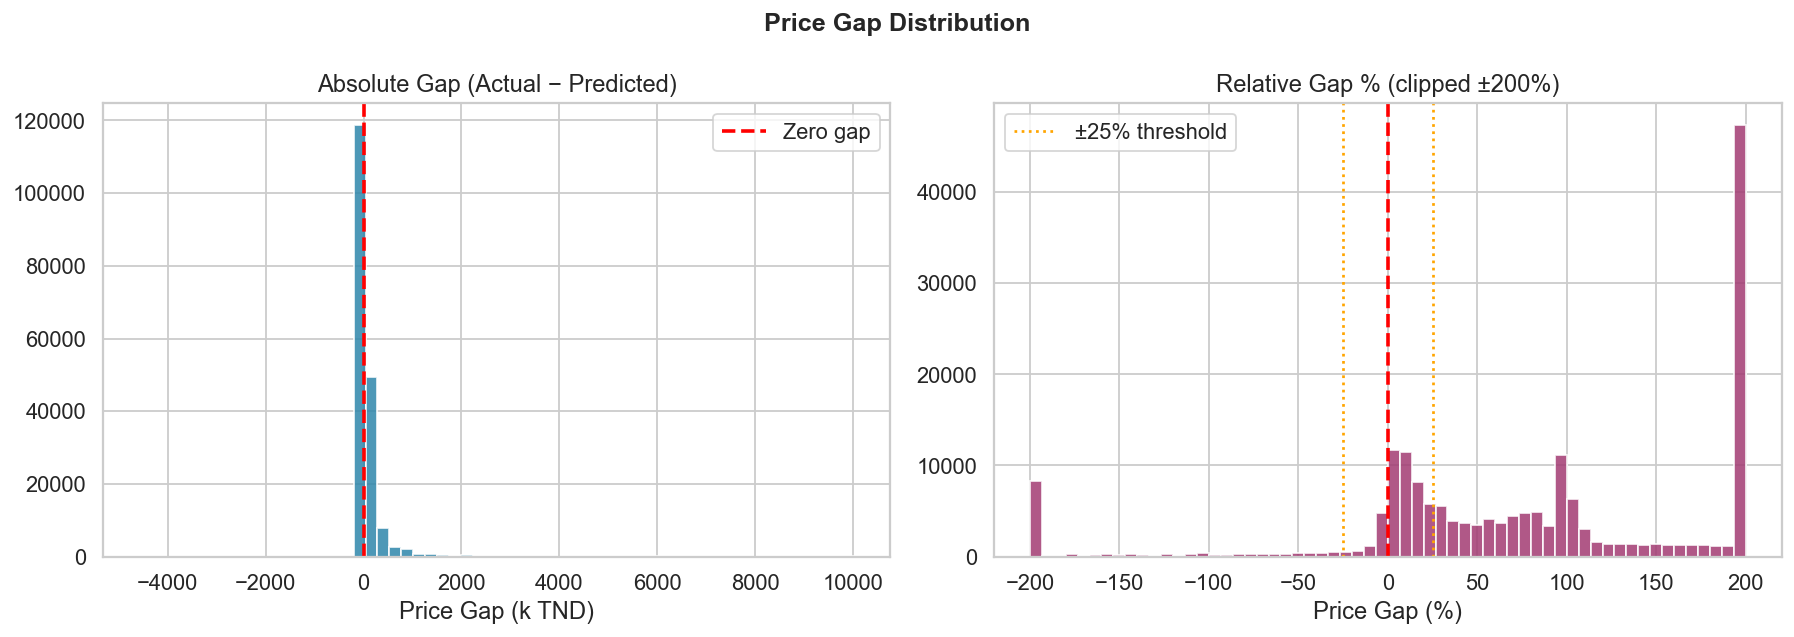

In [7]:
# Distribution of price gap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Gap Distribution', fontsize=14, fontweight='bold')

clip = df_scored['price_gap_pct'].clip(-200, 200)
axes[0].hist(df_scored['price_gap'] / 1000, bins=60, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', lw=2, linestyle='--', label='Zero gap')
axes[0].set_xlabel('Price Gap (k TND)'); axes[0].set_title('Absolute Gap (Actual − Predicted)')
axes[0].legend()

axes[1].hist(clip, bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].axvline(-25, color='orange', lw=1.5, linestyle=':', label='±25% threshold')
axes[1].axvline(25,  color='orange', lw=1.5, linestyle=':')
axes[1].set_xlabel('Price Gap (%)'); axes[1].set_title('Relative Gap % (clipped ±200%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('price_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Keep only listings where both prix and predicted_price are within realistic bounds
MIN_PRICE = 10000    
MAX_PRICE = 5000000  
MAX_GAP   = 90       

df_scored_clean = df_scored[
    (df_scored['prix'] >= MIN_PRICE) &
    (df_scored['prix'] <= MAX_PRICE) &
    (df_scored['predicted_price'] >= MIN_PRICE) &
    (df_scored['predicted_price'] <= MAX_PRICE) &
    (df_scored['price_gap_pct'].abs() <= MAX_GAP)
].copy()

print(f"After filtering: {len(df_scored_clean):,} listings (removed {len(df_scored)-len(df_scored_clean):,})")
print(df_scored_clean['price_gap_pct'].describe().round(2))

After filtering: 69,256 listings (removed 115,118)
count    69256.00
mean        28.15
std         27.05
min        -89.06
25%          6.91
50%         19.50
75%         49.01
max         89.96
Name: price_gap_pct, dtype: float64


## 6. Multi-Method Anomaly Scoring

Three complementary methods are combined into a single **anomaly score**:

| Method | What it catches |
|--------|----------------|
| **Z-score** | Listings far from the mean gap in standard deviations |
| **IQR fence** | Listings beyond the 1.5×IQR whiskers |
| **Isolation Forest** | Multivariate anomalies across all features |

A listing is flagged when **≥ 2 out of 3** methods agree.

In [9]:
# ── Method 1: Z-score on price_gap_pct ──
z_scores = np.abs(stats.zscore(df_scored['price_gap_pct'].fillna(0)))
df_scored['zscore_anomaly'] = (z_scores > 2.5).astype(int)

# ── Method 2: IQR fence ──
Q1  = df_scored['price_gap_pct'].quantile(0.25)
Q3  = df_scored['price_gap_pct'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 2.0 * IQR
upper_fence = Q3 + 2.0 * IQR
df_scored['iqr_anomaly'] = (
    (df_scored['price_gap_pct'] < lower_fence) |
    (df_scored['price_gap_pct'] > upper_fence)
).astype(int)

# ── Method 3: Isolation Forest (multivariate) ──
iso_features = ['prix', 'predicted_price', 'price_gap_pct'] + [
    c for c in ['surface', 'pieces', 'dist_to_center', 'total_amenities', 'price_per_m2']
    if c in df_scored.columns
]
X_iso = df_scored[iso_features].fillna(df_scored[iso_features].median())

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # expect ~5% anomalies
    random_state=RANDOM_SEED,
    n_jobs=-1
)
df_scored['iso_score']   = iso.fit_predict(X_iso)   # -1 = anomaly
df_scored['iso_anomaly'] = (df_scored['iso_score'] == -1).astype(int)
df_scored['iso_raw_score'] = iso.decision_function(X_iso)  # lower = more anomalous

# ── Consensus flag: ≥2 methods agree ──
df_scored['anomaly_votes'] = (
    df_scored['zscore_anomaly'] +
    df_scored['iqr_anomaly'] +
    df_scored['iso_anomaly']
)
df_scored['is_anomaly'] = (df_scored['anomaly_votes'] >= 2).astype(int)

n_anomalies = df_scored['is_anomaly'].sum()
print(f"Anomalies detected (≥2/3 methods): {n_anomalies:,} / {len(df_scored):,} ({n_anomalies/len(df_scored)*100:.1f}%)")
print(f"  Z-score only  : {df_scored['zscore_anomaly'].sum():,}")
print(f"  IQR only      : {df_scored['iqr_anomaly'].sum():,}")
print(f"  Isolation F.  : {df_scored['iso_anomaly'].sum():,}")

Anomalies detected (≥2/3 methods): 2,223 / 184,374 (1.2%)
  Z-score only  : 1,962
  IQR only      : 29,335
  Isolation F.  : 9,219


## 7. Opportunity & Risk Labelling
Each anomaly is classified into one of four categories based on the direction and magnitude of the price gap.

In [10]:
# More robust gap: use predicted_price as denominator, and filter garbage predictions
df_scored['price_gap_pct'] = (
    (df_scored['prix'] - df_scored['predicted_price']) 
    / df_scored['predicted_price'].abs().clip(lower=1000)
) * 100

# Clip extreme values caused by near-zero predictions
df_scored['price_gap_pct'] = df_scored['price_gap_pct'].clip(-200, 200)

def label_opportunity(row):
    if row['is_anomaly'] == 0:
        return 'Normal'
    gap = row['price_gap_pct']
    if gap < -20:
        return 'Strong Opportunity'
    elif gap < -10:
        return 'Opportunity'
    elif gap > 20:
        return 'Overpriced Risk'
    elif gap > 10:
        return 'Slight Overpricing'
    else:
        return 'Borderline'

df_scored['opportunity_label'] = df_scored.apply(label_opportunity, axis=1)
label_counts = df_scored['opportunity_label'].value_counts()
print(label_counts.to_string())

opportunity_label
Normal                182151
Overpriced Risk         1982
Strong Opportunity       241


In [11]:
print(df_scored[df_scored['is_anomaly']==1]['price_gap_pct'].describe().round(2))
print(df_scored[df_scored['is_anomaly']==1]['price_gap_pct'].value_counts(bins=10).sort_index())

count    2223.00
mean       80.15
std        61.41
min       -99.98
25%       100.59
50%       101.02
75%       101.50
max       120.67
Name: price_gap_pct, dtype: float64
(-100.20100000000001, -77.915]     241
(-77.915, -55.85]                    0
(-55.85, -33.785]                    0
(-33.785, -11.721]                   0
(-11.721, 10.344]                    0
(10.344, 32.409]                     0
(32.409, 54.474]                     0
(54.474, 76.539]                     0
(76.539, 98.603]                     0
(98.603, 120.668]                 1982
Name: count, dtype: int64


In [12]:
# ── Confidence score ──
# Higher confidence when: iso_raw_score is very negative AND z-score is high
from sklearn.preprocessing import MinMaxScaler

conf_features = pd.DataFrame({
    'abs_gap_pct' : df_scored['price_gap_pct'].abs(),
    'z_score'     : np.abs(stats.zscore(df_scored['price_gap_pct'].fillna(0))),
    'iso_neg'     : -df_scored['iso_raw_score'],   # more negative = more anomalous
    'vote_count'  : df_scored['anomaly_votes'],
})
scaler_conf = MinMaxScaler()
conf_norm = scaler_conf.fit_transform(conf_features.fillna(0))
df_scored['anomaly_confidence'] = np.round(conf_norm.mean(axis=1), 3)

# Only meaningful for flagged anomalies
df_scored.loc[df_scored['is_anomaly'] == 0, 'anomaly_confidence'] = 0.0

print(df_scored.loc[df_scored['is_anomaly']==1, 'anomaly_confidence'].describe().round(3))

count    2223.000
mean        0.448
std         0.091
min         0.356
25%         0.381
50%         0.398
75%         0.502
max         0.821
Name: anomaly_confidence, dtype: float64


## 8. Visualisations

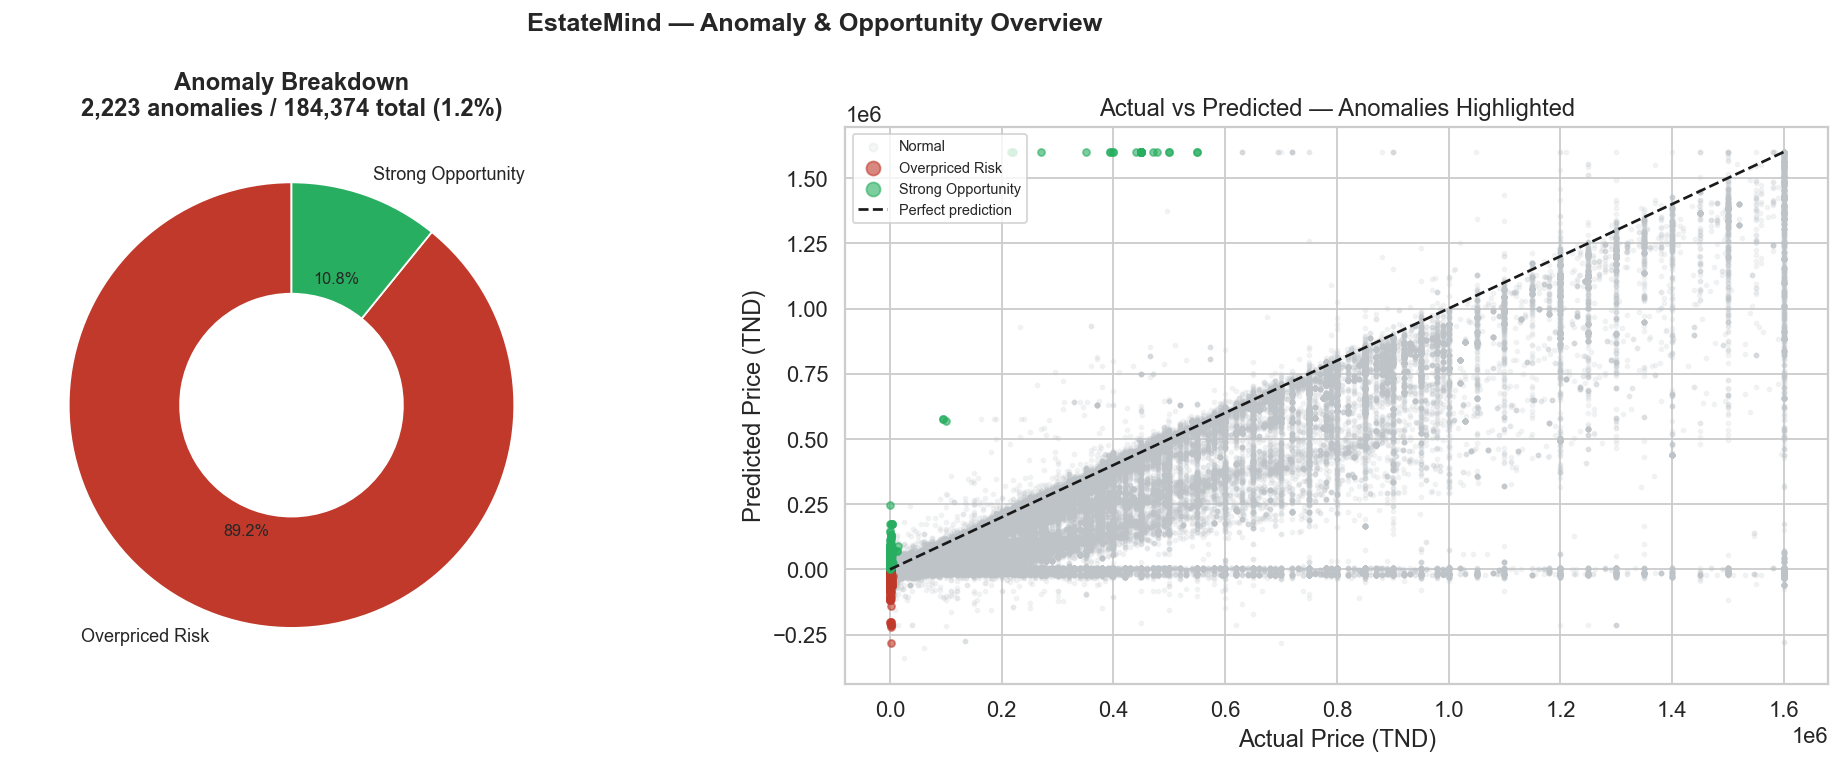

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EstateMind — Anomaly & Opportunity Overview', fontsize=14, fontweight='bold')

color_map = {
    'Normal':             '#95a5a6',
    'Strong Opportunity': '#27ae60',
    'Opportunity':        '#2ecc71',
    'Slight Overpricing': '#e67e22',
    'Overpriced Risk':    '#c0392b',
    'Borderline':         '#8e44ad',
}

# ── 8.1 Donut chart — anomaly breakdown excluding Normal ──
anomaly_counts = {k: v for k, v in label_counts.items() if k != 'Normal' and v > 0}
donut_labels = list(anomaly_counts.keys())
donut_values = list(anomaly_counts.values())
donut_colors = [color_map[l] for l in donut_labels]

wedges, texts, autotexts = axes[0].pie(
    donut_values,
    labels=donut_labels,
    colors=donut_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)

total_anomalies = sum(donut_values)
total_listings  = len(df_scored)
axes[0].set_title(
    f'Anomaly Breakdown\n{total_anomalies:,} anomalies / {total_listings:,} total ({total_anomalies/total_listings*100:.1f}%)',
    fontweight='bold'
)

# ── 8.2 Scatter: actual vs predicted, coloured by label ──
anomalies_only = df_scored[df_scored['is_anomaly'] == 1]
normal_only    = df_scored[df_scored['is_anomaly'] == 0]
clip_q = float(df_scored['prix'].quantile(0.97))

axes[1].scatter(
    normal_only['prix'].clip(upper=clip_q),
    normal_only['predicted_price'].clip(upper=clip_q),
    alpha=0.15, s=5, color='#bdc3c7', label='Normal'
)
for label, grp in anomalies_only.groupby('opportunity_label'):
    axes[1].scatter(
        grp['prix'].clip(upper=clip_q),
        grp['predicted_price'].clip(upper=clip_q),
        alpha=0.6, s=15, color=color_map.get(label, '#95a5a6'), label=label
    )
lo, hi = 0, clip_q
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Price (TND)')
axes[1].set_ylabel('Predicted Price (TND)')
axes[1].set_title('Actual vs Predicted — Anomalies Highlighted')
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('anomaly_overview.png', dpi=150, bbox_inches='tight')
plt.show()

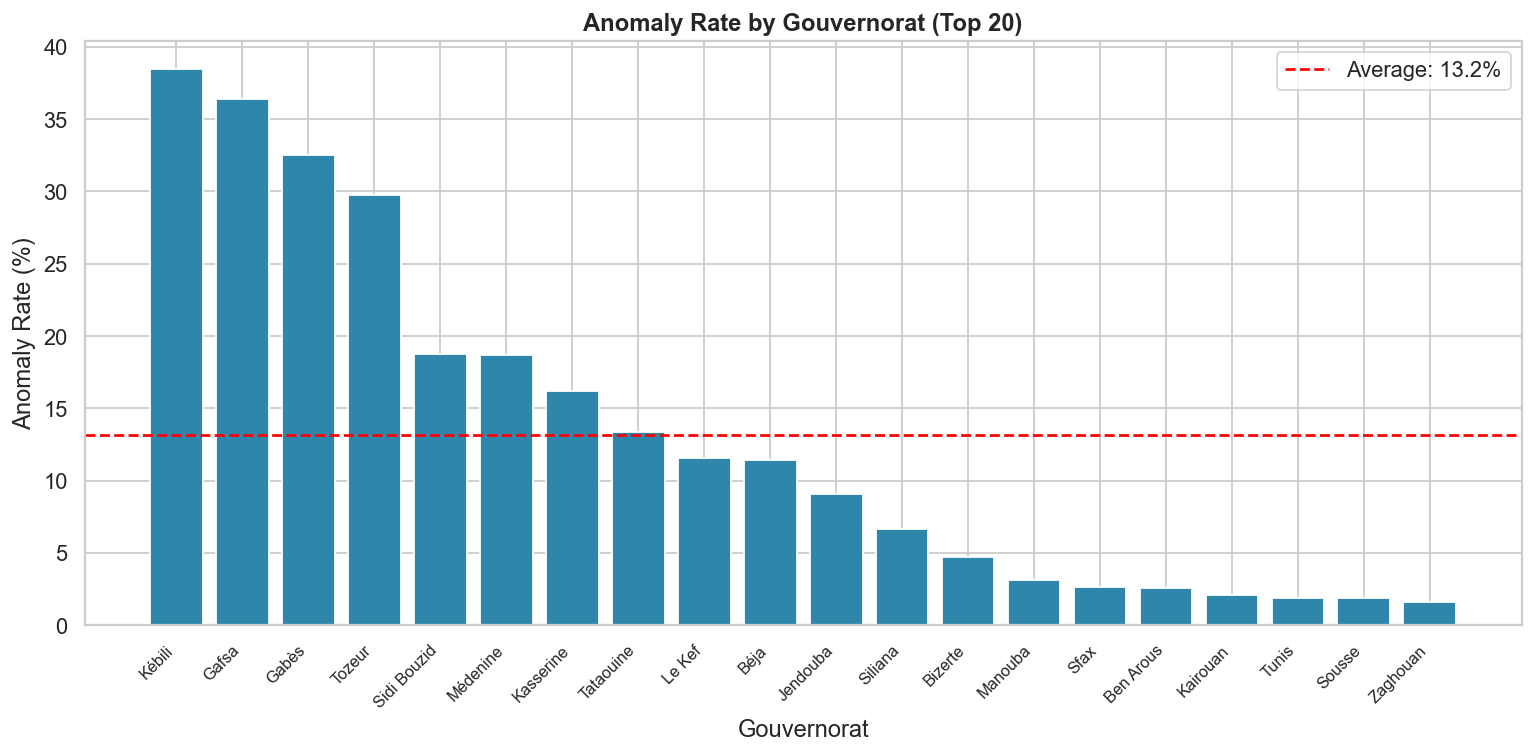

In [14]:
# ── 8.3 Anomaly rate by gouvernorat ──
gov_stats = (
    df_scored.groupby('gouvernerat')
    .agg(total=('is_anomaly','count'), anomalies=('is_anomaly','sum'))
    .assign(anomaly_rate=lambda x: x['anomalies'] / x['total'] * 100)
    .sort_values('anomaly_rate', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(gov_stats.index, gov_stats['anomaly_rate'],
              color=PALETTE[0], edgecolor='white')
ax.axhline(gov_stats['anomaly_rate'].mean(), color='red', lw=1.5,
           linestyle='--', label=f"Average: {gov_stats['anomaly_rate'].mean():.1f}%")
ax.set_title('Anomaly Rate by Gouvernorat (Top 20)', fontweight='bold')
ax.set_xlabel('Gouvernorat')
ax.set_ylabel('Anomaly Rate (%)')
ax.set_xticklabels(gov_stats.index, rotation=45, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('anomaly_rate_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

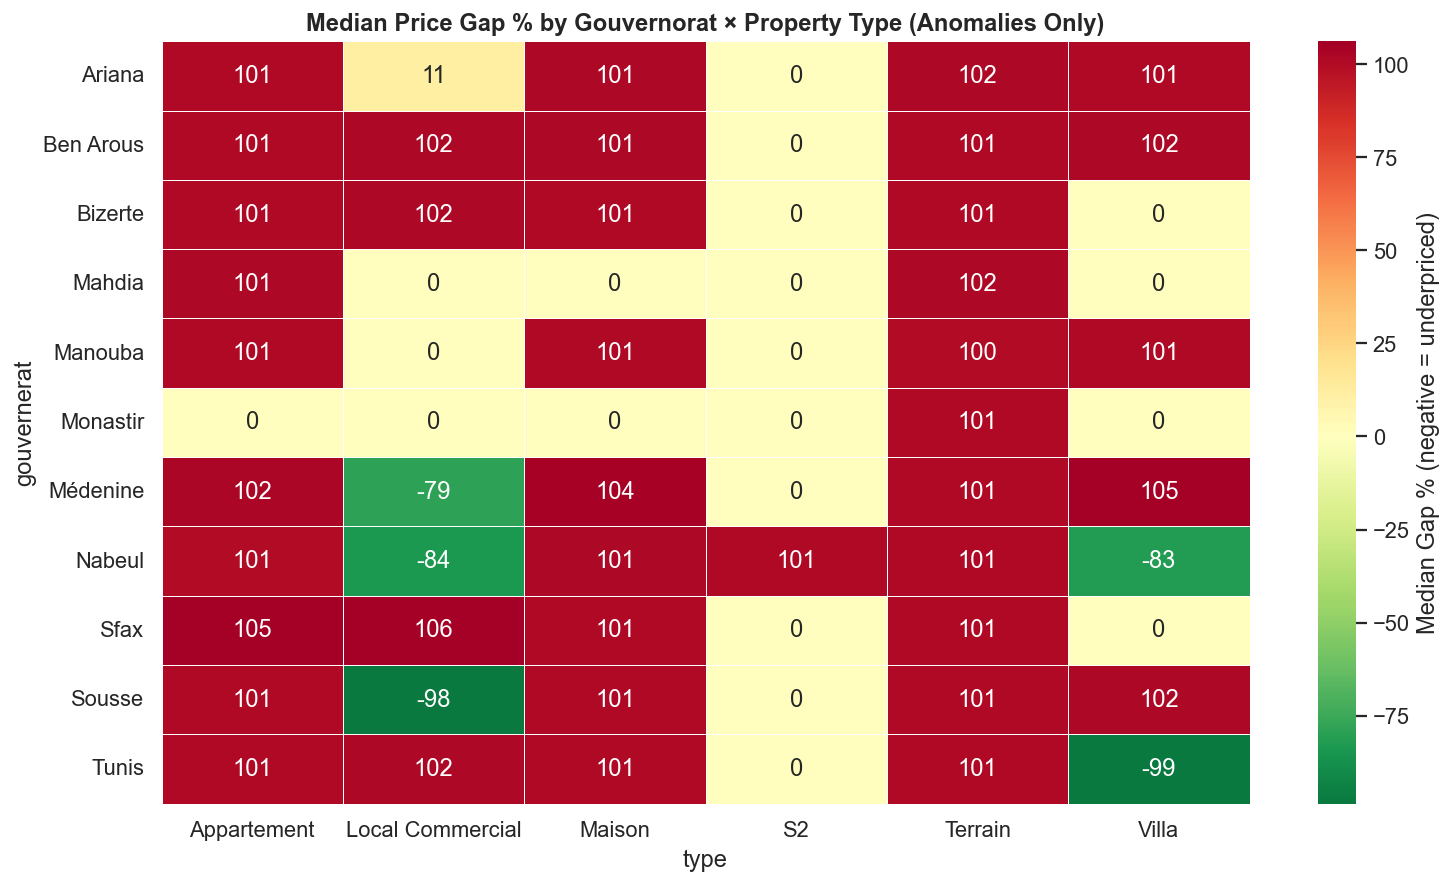

In [15]:
# ── 8.4 Price gap heatmap: gouvernorat × property type ──
if 'type' in df_scored.columns and 'gouvernerat' in df_scored.columns:
    pivot = (
        df_scored[df_scored['is_anomaly'] == 1]
        .groupby(['gouvernerat', 'type'])['price_gap_pct']
        .median()
        .unstack(fill_value=0)
    )
    top_govs  = df_scored['gouvernerat'].value_counts().head(12).index
    top_types = df_scored['type'].value_counts().head(6).index
    pivot = pivot.loc[pivot.index.isin(top_govs), pivot.columns.isin(top_types)]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(
        pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
        center=0, linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Median Gap % (negative = underpriced)'}
    )
    ax.set_title('Median Price Gap % by Gouvernorat × Property Type (Anomalies Only)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig('anomaly_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

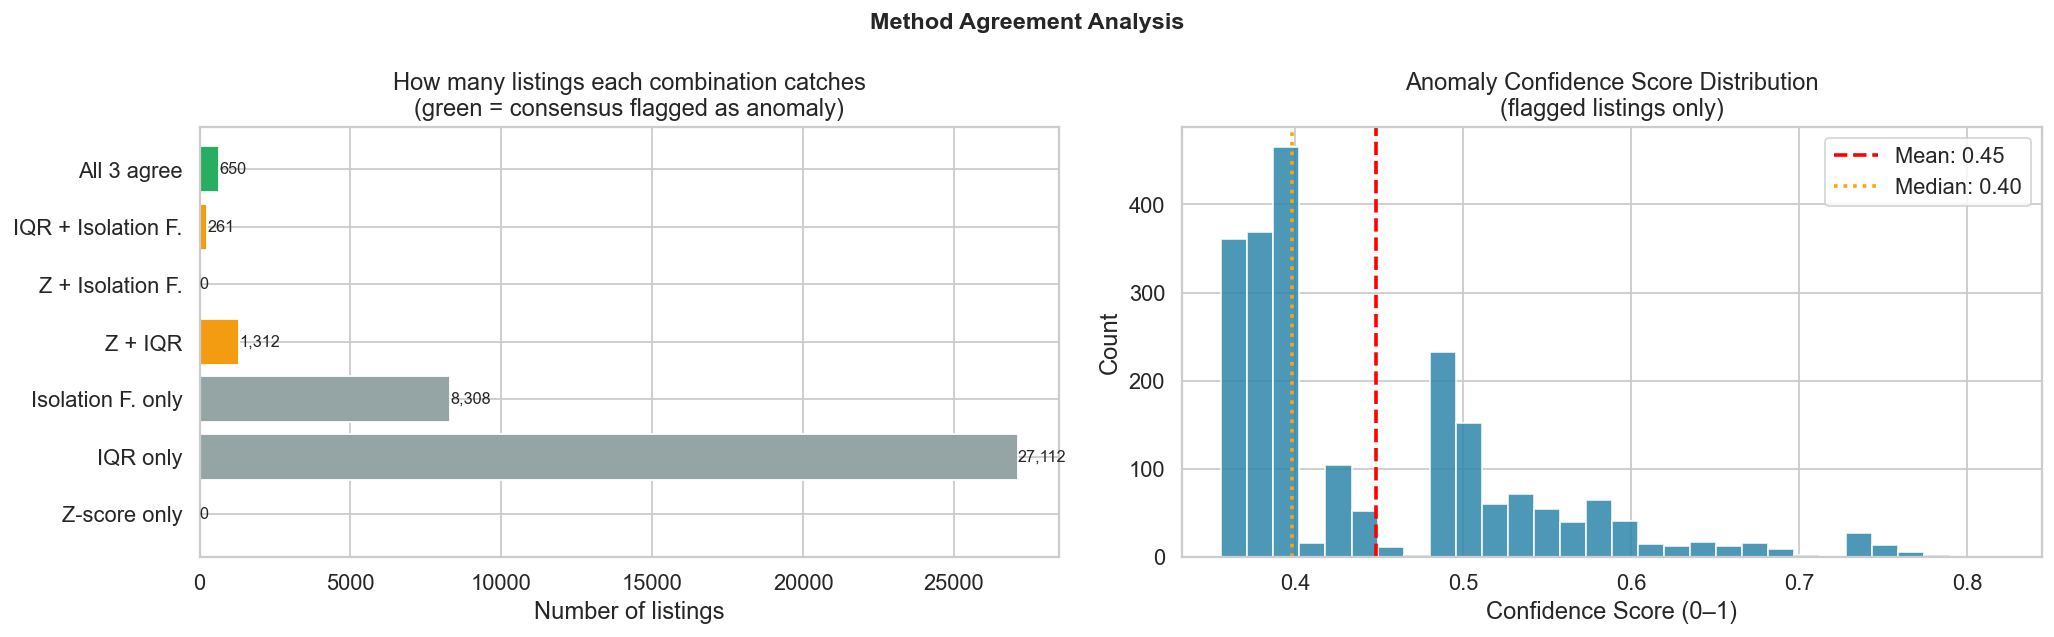

In [16]:
# ── Method Agreement Analysis ──────────────────────────────────────────────
combos = {
    'Z-score only'       : ((df_scored['zscore_anomaly']==1) & (df_scored['iqr_anomaly']==0) & (df_scored['iso_anomaly']==0)).sum(),
    'IQR only'           : ((df_scored['zscore_anomaly']==0) & (df_scored['iqr_anomaly']==1) & (df_scored['iso_anomaly']==0)).sum(),
    'Isolation F. only'  : ((df_scored['zscore_anomaly']==0) & (df_scored['iqr_anomaly']==0) & (df_scored['iso_anomaly']==1)).sum(),
    'Z + IQR'            : ((df_scored['zscore_anomaly']==1) & (df_scored['iqr_anomaly']==1) & (df_scored['iso_anomaly']==0)).sum(),
    'Z + Isolation F.'   : ((df_scored['zscore_anomaly']==1) & (df_scored['iqr_anomaly']==0) & (df_scored['iso_anomaly']==1)).sum(),
    'IQR + Isolation F.' : ((df_scored['zscore_anomaly']==0) & (df_scored['iqr_anomaly']==1) & (df_scored['iso_anomaly']==1)).sum(),
    'All 3 agree'        : ((df_scored['zscore_anomaly']==1) & (df_scored['iqr_anomaly']==1) & (df_scored['iso_anomaly']==1)).sum(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Method Agreement Analysis', fontsize=13, fontweight='bold')

colors_combo = ['#95a5a6','#95a5a6','#95a5a6','#f39c12','#f39c12','#f39c12','#27ae60']
bars = axes[0].barh(list(combos.keys()), list(combos.values()), color=colors_combo, edgecolor='white')
for bar, val in zip(bars, combos.values()):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('How many listings each combination catches\n(green = consensus flagged as anomaly)')
axes[0].set_xlabel('Number of listings')

# Confidence score distribution for flagged anomalies
anomaly_conf = df_scored[df_scored['is_anomaly']==1]['anomaly_confidence']
axes[1].hist(anomaly_conf, bins=30, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[1].axvline(anomaly_conf.mean(), color='red', lw=2, linestyle='--',
                label=f'Mean: {anomaly_conf.mean():.2f}')
axes[1].axvline(anomaly_conf.median(), color='orange', lw=2, linestyle=':',
                label=f'Median: {anomaly_conf.median():.2f}')
axes[1].set_title('Anomaly Confidence Score Distribution\n(flagged listings only)')
axes[1].set_xlabel('Confidence Score (0–1)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('method_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

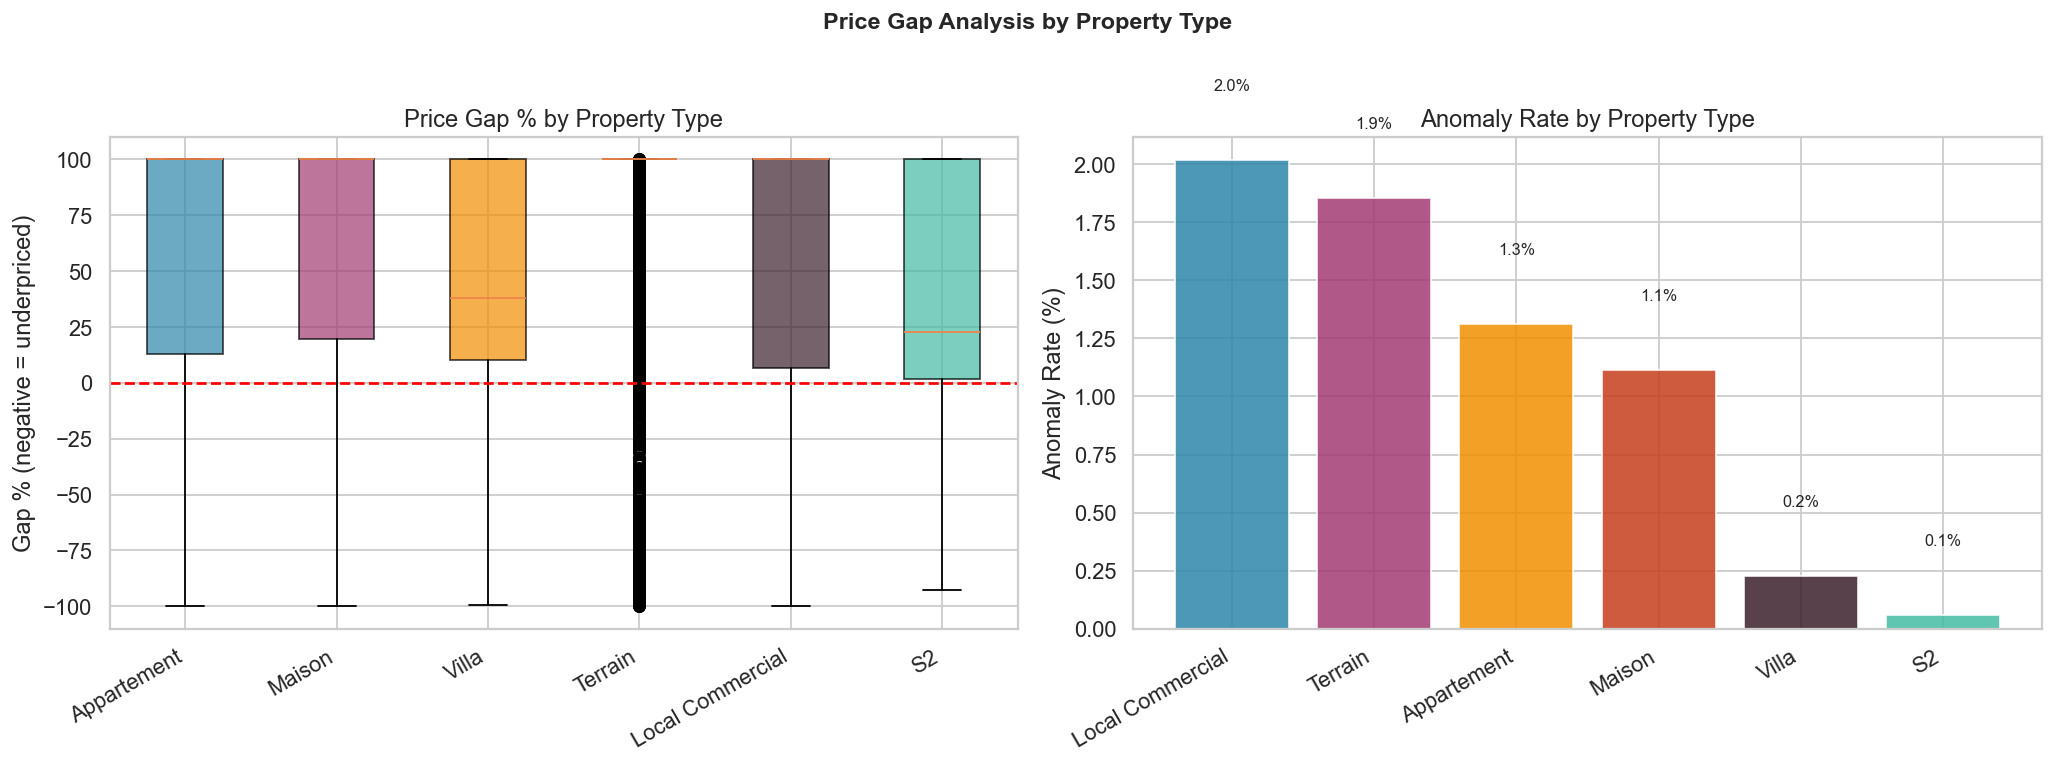

In [17]:
# ── Price gap distribution by property type ────────────────────────────────
if 'type' in df_scored.columns:
    top_types = df_scored['type'].value_counts().head(6).index
    df_types  = df_scored[df_scored['type'].isin(top_types)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Price Gap Analysis by Property Type', fontsize=13, fontweight='bold')

    # Boxplot of gap % per type
    type_data = [df_types[df_types['type']==t]['price_gap_pct'].clip(-100,100).dropna()
                 for t in top_types]
    bp = axes[0].boxplot(type_data, labels=top_types, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
    axes[0].set_title('Price Gap % by Property Type')
    axes[0].set_ylabel('Gap % (negative = underpriced)')
    axes[0].set_xticklabels(top_types, rotation=30, ha='right')

    # Anomaly rate per type
    type_stats = (df_types.groupby('type')
                  .agg(total=('is_anomaly','count'), anomalies=('is_anomaly','sum'))
                  .assign(rate=lambda x: x['anomalies']/x['total']*100)
                  .sort_values('rate', ascending=False))
    axes[1].bar(type_stats.index, type_stats['rate'],
                color=PALETTE[:len(type_stats)], edgecolor='white', alpha=0.85)
    axes[1].set_title('Anomaly Rate by Property Type')
    axes[1].set_ylabel('Anomaly Rate (%)')
    axes[1].set_xticklabels(type_stats.index, rotation=30, ha='right')
    for i, (idx, row) in enumerate(type_stats.iterrows()):
        axes[1].text(i, row['rate'] + 0.3, f"{row['rate']:.1f}%", ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('gap_by_property_type.png', dpi=150, bbox_inches='tight')
    plt.show()

In [26]:
# ── Top 20 investment opportunities ────────────────────────────────────────
display_cols = [c for c in ['gouvernerat', 'ville', 'type', 'surface',
                             'prix', 'predicted_price', 'price_gap_pct', 'anomaly_confidence']
                if c in df_scored.columns]

top_opps = (
    df_scored[
        (df_scored['opportunity_label'].isin(['Strong Opportunity', 'Opportunity'])) &
        (df_scored['prix'] >= 5000)  # filter out data entry errors (prices in TND not thousands)
    ]
    .sort_values('price_gap_pct', ascending=True)
    .head(20)[display_cols]
    .copy()
)

top_opps['prix']               = top_opps['prix'].map('{:,.0f} TND'.format)
top_opps['predicted_price']    = top_opps['predicted_price'].map('{:,.0f} TND'.format)
top_opps['price_gap_pct']      = top_opps['price_gap_pct'].map('{:+.1f}%'.format)
top_opps['anomaly_confidence'] = top_opps['anomaly_confidence'].map('{:.2f}'.format)

print('🟢 TOP 20 INVESTMENT OPPORTUNITIES')
print('=' * 90)
print(top_opps.to_string(index=False))

🟢 TOP 20 INVESTMENT OPPORTUNITIES
gouvernerat             type  surface        prix predicted_price price_gap_pct anomaly_confidence
      Gabès           Maison      5.0 270,000 TND   3,777,985 TND        -92.9%               0.73
     Nabeul          Terrain      5.0 217,000 TND   2,754,894 TND        -92.1%               0.70
     Nabeul          Terrain      5.0 220,000 TND   2,754,894 TND        -92.0%               0.70
     Nabeul            Villa   4080.0   6,500 TND      74,681 TND        -91.3%               0.63
     Nabeul          Terrain      6.0 350,000 TND   2,754,894 TND        -87.3%               0.69
     Nabeul          Terrain      5.0 393,975 TND   2,754,894 TND        -85.7%               0.69
     Nabeul          Terrain      5.0 393,975 TND   2,754,894 TND        -85.7%               0.69
     Nabeul          Terrain      8.0 400,000 TND   2,754,894 TND        -85.5%               0.68
     Nabeul          Terrain      8.0 400,000 TND   2,754,894 TND        -8

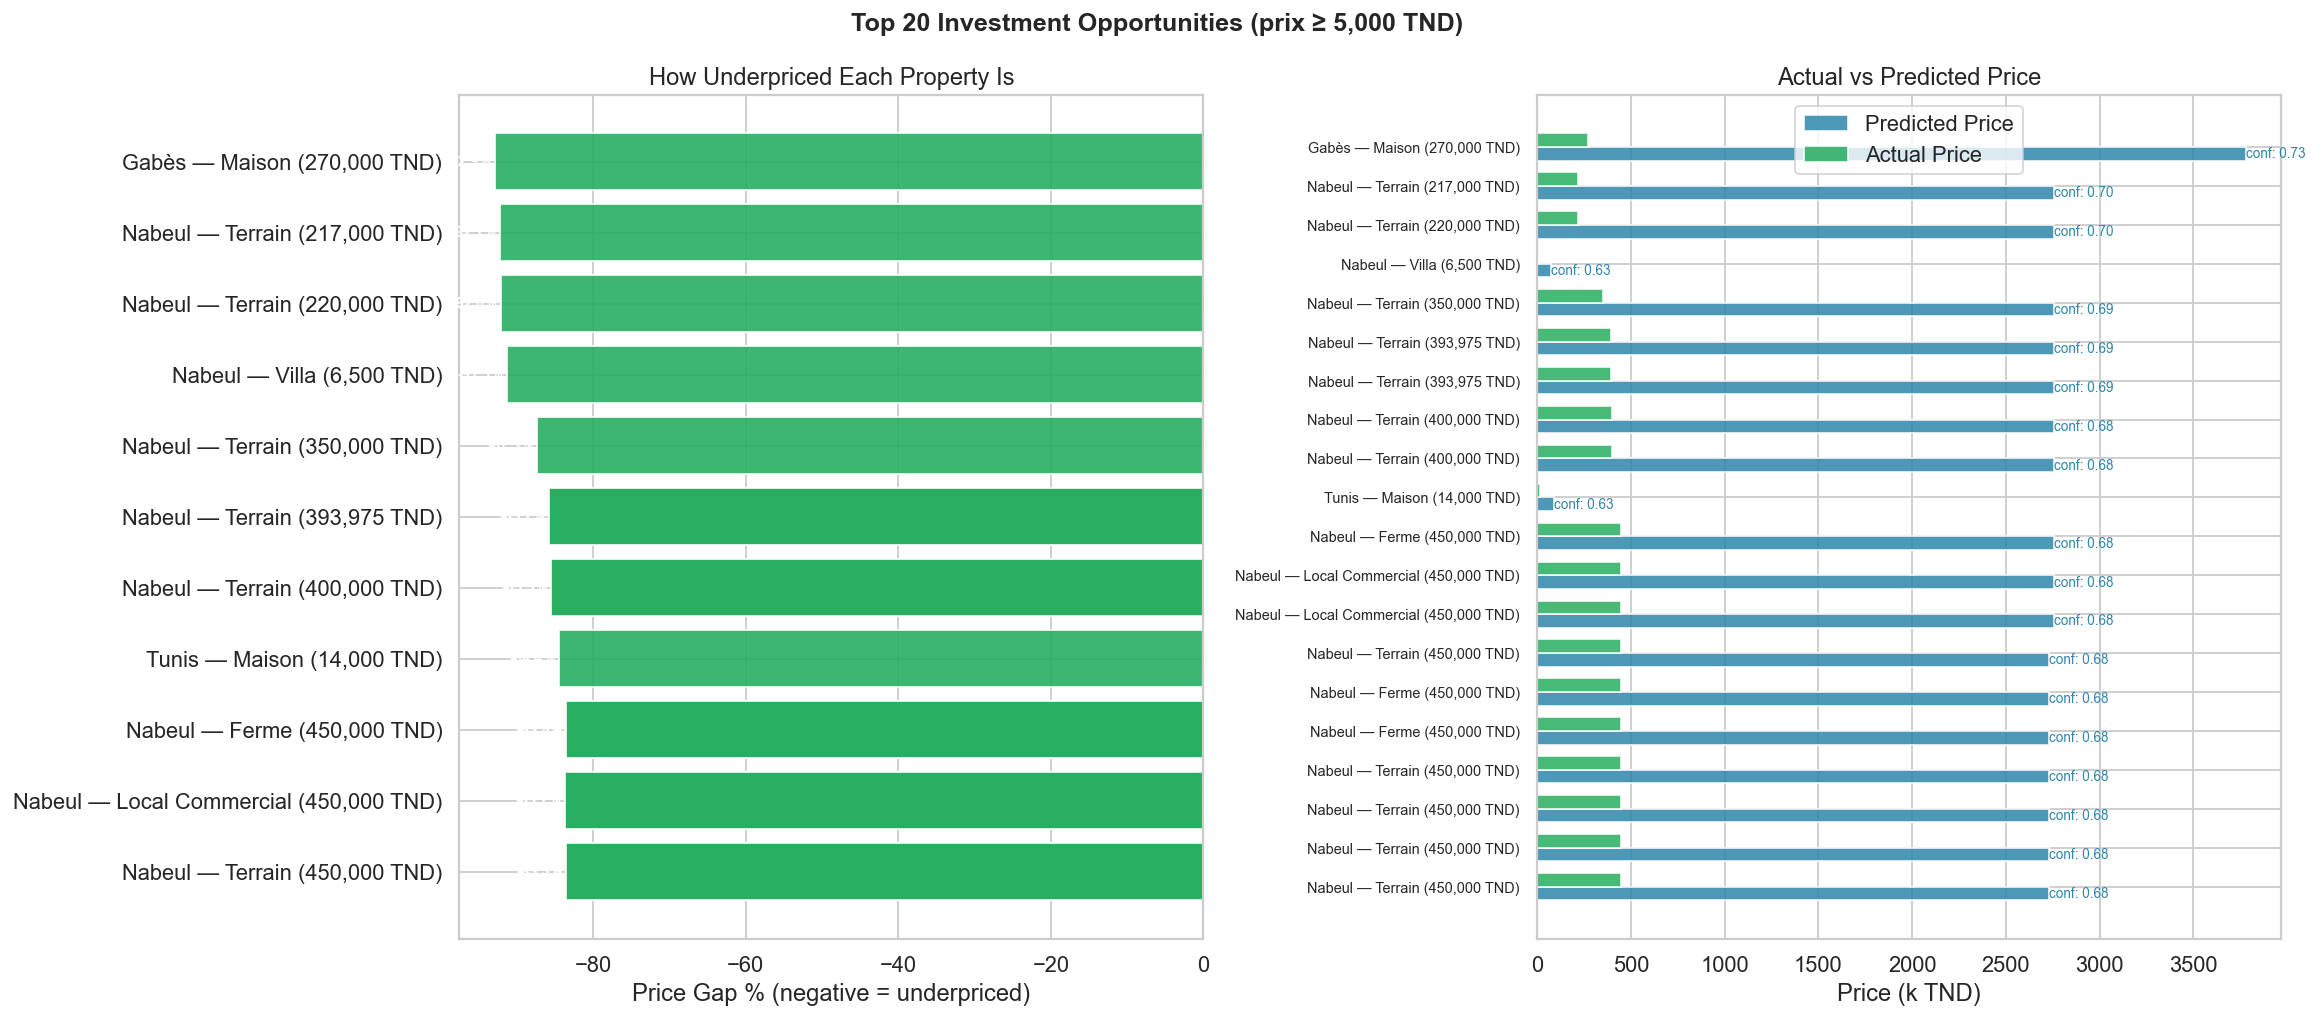

In [27]:
# ── Top 20 opportunities — visual ──────────────────────────────────────────
plot_data = (
    df_scored[
        (df_scored['opportunity_label'].isin(['Strong Opportunity', 'Opportunity'])) &
        (df_scored['prix'] >= 5000)
    ]
    .sort_values('price_gap_pct', ascending=True)
    .head(20)
    .copy()
    .reset_index(drop=True)
)

plot_data['label'] = (
    plot_data.get('gouvernerat', pd.Series(['?']*len(plot_data))).fillna('?').astype(str)
    + ' — '
    + plot_data.get('type', pd.Series(['?']*len(plot_data))).fillna('?').astype(str)
    + ' ('
    + plot_data['prix'].map('{:,.0f}'.format)
    + ' TND)'
)

colors = ['#27ae60' if g == 'Strong Opportunity' else '#2ecc71'
          for g in plot_data['opportunity_label']]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 20 Investment Opportunities (prix ≥ 5,000 TND)', fontsize=14, fontweight='bold')

# ── Left: Gap % bar ──
bars = axes[0].barh(plot_data['label'], plot_data['price_gap_pct'],
                    color=colors, edgecolor='white', alpha=0.9)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('Price Gap % (negative = underpriced)')
axes[0].set_title('How Underpriced Each Property Is')
axes[0].invert_yaxis()
for bar, val in zip(bars, plot_data['price_gap_pct']):
    axes[0].text(val - 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:+.1f}%', va='center', ha='right', fontsize=8, color='white', fontweight='bold')

# ── Right: Actual vs Predicted price ──
x = np.arange(len(plot_data))
w = 0.35
axes[1].barh(x + w/2, plot_data['predicted_price'] / 1e3, w,
             label='Predicted Price', color='#2E86AB', alpha=0.85, edgecolor='white')
axes[1].barh(x - w/2, plot_data['prix'] / 1e3, w,
             label='Actual Price', color=colors, alpha=0.85, edgecolor='white')
axes[1].set_yticks(x)
axes[1].set_yticklabels(plot_data['label'], fontsize=8)
axes[1].set_xlabel('Price (k TND)')
axes[1].set_title('Actual vs Predicted Price')
axes[1].legend()
axes[1].invert_yaxis()

# Confidence score as text
for i, (_, row) in enumerate(plot_data.iterrows()):
    axes[1].text(row['predicted_price'] / 1e3 + 0.5, i + w/2,
                 f"conf: {row['anomaly_confidence']:.2f}",
                 va='center', fontsize=7.5, color='#2E86AB')

plt.tight_layout()
plt.savefig('top20_opportunities.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SHAP Explanation — Why Is This Property an Anomaly?
Use SHAP to explain which features pushed the predicted price up or down for the most extreme anomalies.

In [19]:
try:
    import shap
    print(f'SHAP {shap.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    print('SHAP installed.')

SHAP 0.49.1


In [20]:
# Explainer on the loaded model (LightGBM or RF)
try:
    explainer = shap.TreeExplainer(loaded_model)
    SHAP_OK = True
    print('TreeExplainer ready.')
except Exception as e:
    print(f'TreeExplainer failed: {e} — using KernelExplainer as fallback')
    bg = shap.sample(X_enc, 100, random_state=RANDOM_SEED)
    explainer = shap.KernelExplainer(loaded_model.predict, bg)
    SHAP_OK = True

TreeExplainer ready.


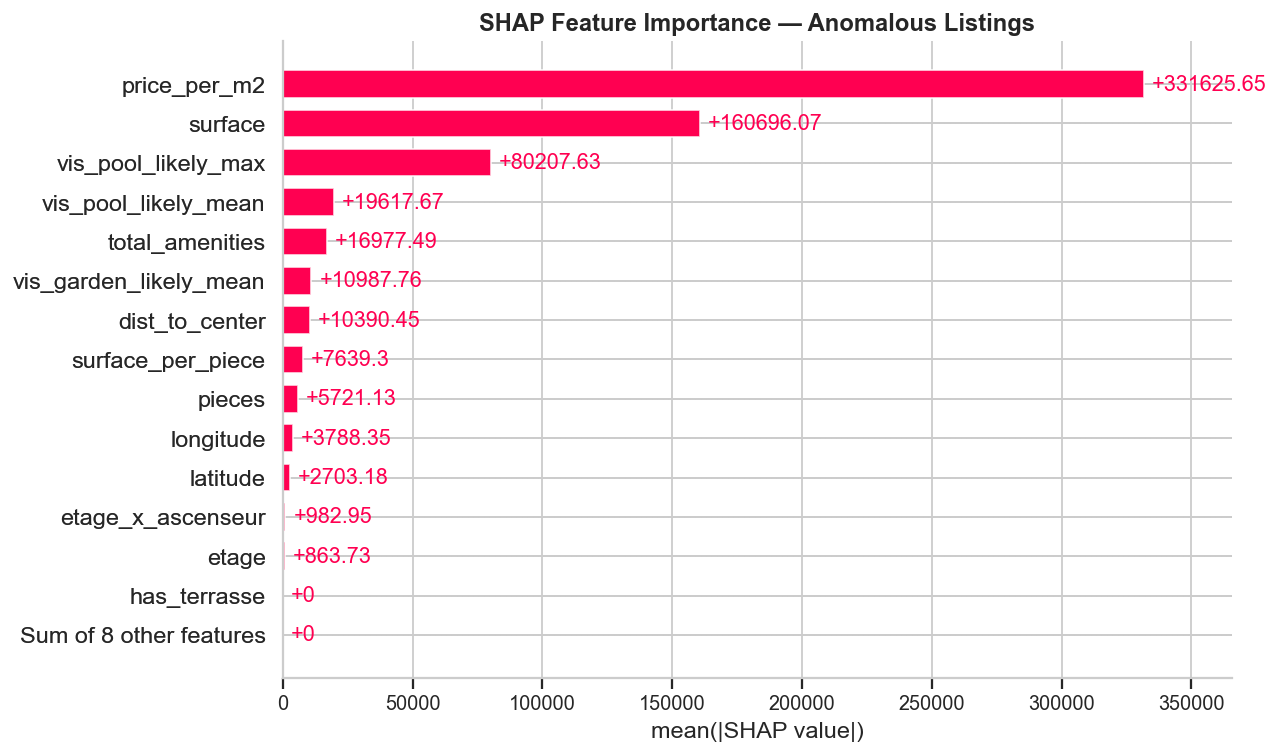

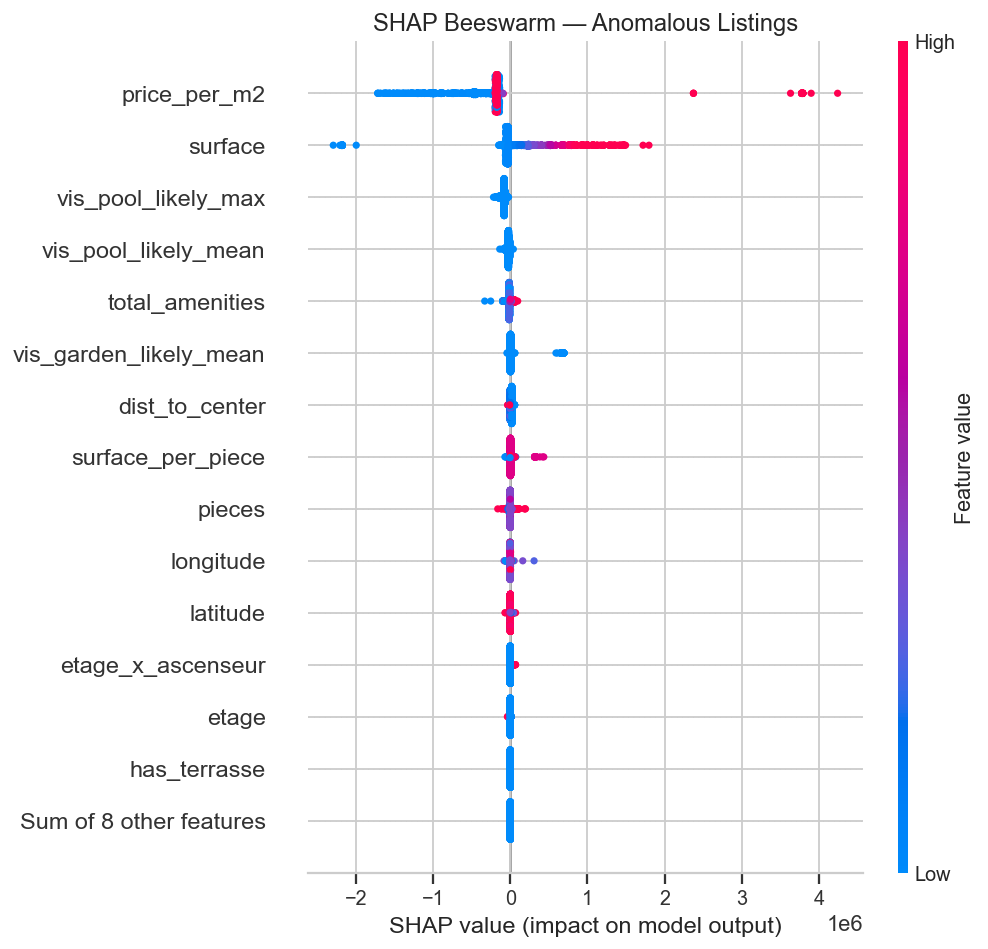

In [21]:
if SHAP_OK:
    # Compute SHAP on anomalies only (faster)
    X_anomaly = X_enc.loc[df_scored[df_scored['is_anomaly'] == 1].index]
    shap_values = explainer(X_anomaly)

    # Global importance for anomalous listings
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.bar(shap_values, max_display=15, show=False, ax=ax)
    ax.set_title('SHAP Feature Importance — Anomalous Listings', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_anomaly_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Beeswarm summary
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title('SHAP Beeswarm — Anomalous Listings')
    plt.tight_layout()
    plt.savefig('shap_anomaly_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

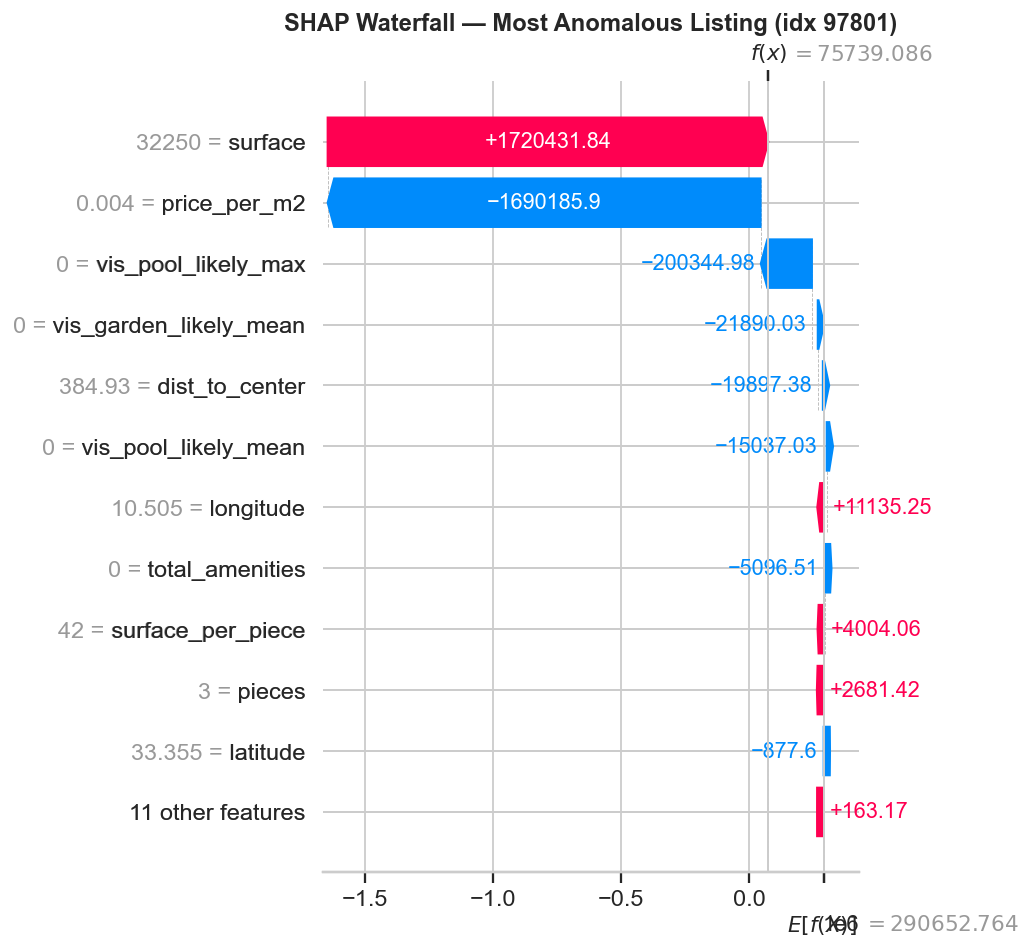


Top anomaly details:
  Actual price     : 125 TND
  Predicted price  : 75,739 TND
  Gap              : -75,614 TND (-99.8%)
  Label            : Strong Opportunity
  Confidence       : 0.821


In [22]:
if SHAP_OK:
    # Waterfall for the single most anomalous listing
    most_anomalous_idx = df_scored.loc[
        df_scored['is_anomaly'] == 1, 'anomaly_confidence'
    ].idxmax()
    row_pos = list(X_anomaly.index).index(most_anomalous_idx)

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values[row_pos], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — Most Anomalous Listing (idx {most_anomalous_idx})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_top_anomaly.png', dpi=150, bbox_inches='tight')
    plt.show()

    row = df_scored.loc[most_anomalous_idx]
    print(f"\nTop anomaly details:")
    print(f"  Actual price     : {row['prix']:,.0f} TND")
    print(f"  Predicted price  : {row['predicted_price']:,.0f} TND")
    print(f"  Gap              : {row['price_gap']:+,.0f} TND ({row['price_gap_pct']:+.1f}%)")
    print(f"  Label            : {row['opportunity_label']}")
    print(f"  Confidence       : {row['anomaly_confidence']:.3f}")

## 10. Interactive Map of Anomalies
Plot all anomalous listings on a Folium map, coloured by opportunity label.

In [23]:
try:
    import folium
    from folium.plugins import MarkerCluster, HeatMap, MiniMap
    FOLIUM_OK = True
    print(f'Folium ready.')
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'folium', '-q'])
    import folium
    from folium.plugins import MarkerCluster, HeatMap, MiniMap
    FOLIUM_OK = True

Folium ready.


In [24]:
if FOLIUM_OK:
    GOV_COORDS = {
        'Tunis':(36.8189,10.1658),'Ariana':(36.8665,10.1647),'Ben Arous':(36.7533,10.2282),
        'Manouba':(36.8093,10.0963),'Nabeul':(36.4561,10.7376),'Zaghouan':(36.4029,10.1434),
        'Bizerte':(37.2744,9.8739),'Beja':(36.7333,9.1833),'Jendouba':(36.5011,8.7757),
        'Le Kef':(36.1825,8.7147),'Siliana':(36.0851,9.3709),'Sousse':(35.8288,10.6363),
        'Monastir':(35.7643,10.8113),'Mahdia':(35.5047,11.0622),'Sfax':(34.7400,10.7600),
        'Kairouan':(35.6781,10.0968),'Kasserine':(35.1672,8.8306),'Sidi Bouzid':(35.0382,9.4849),
        'Gabes':(33.8828,10.0982),'Medenine':(33.3549,10.5055),'Tataouine':(32.9293,10.4509),
        'Gafsa':(34.4250,8.7842),'Tozeur':(33.9197,8.1335),'Kebili':(33.7050,8.9690),
    }
    LABEL_COLORS = {
        'Strong Opportunity': 'green',
        'Opportunity':        'lightgreen',
        'Borderline':         'purple',
        'Slight Overpricing': 'orange',
        'Overpriced Risk':    'red',
        'Normal':             'gray',
    }

    df_map = df_scored[df_scored['is_anomaly'] == 1].copy()
    df_map['_lat'] = pd.to_numeric(df_map.get('latitude', np.nan), errors='coerce')
    df_map['_lon'] = pd.to_numeric(df_map.get('longitude', np.nan), errors='coerce')

    if 'gouvernerat' in df_map.columns:
        for gov, (lat_g, lon_g) in GOV_COORDS.items():
            mask = df_map['_lat'].isna() & df_map['gouvernerat'].str.contains(gov, case=False, na=False)
            df_map.loc[mask, '_lat'] = lat_g + np.random.uniform(-0.05, 0.05, mask.sum())
            df_map.loc[mask, '_lon'] = lon_g + np.random.uniform(-0.05, 0.05, mask.sum())

    df_map = df_map.dropna(subset=['_lat','_lon']).head(2000)

    m = folium.Map(location=[33.8869, 9.5375], zoom_start=7, tiles='CartoDB positron')
    MiniMap(toggle_display=True).add_to(m)

    # Cluster layer
    cluster = MarkerCluster(name='Anomalies (clustered)').add_to(m)

    for _, row in df_map.iterrows():
        color  = LABEL_COLORS.get(row['opportunity_label'], 'gray')
        gap_pct = row['price_gap_pct']
        conf    = row['anomaly_confidence']
        titre   = str(row.get('titre', 'N/A'))[:80]
        popup_html = (
            f"<b>{titre}</b><br>"
            f"Actual: <b>{row['prix']:,.0f} TND</b><br>"
            f"Predicted: {row['predicted_price']:,.0f} TND<br>"
            f"Gap: <b style='color:{'green' if gap_pct<0 else 'red'}'>"
            f"{gap_pct:+.1f}%</b><br>"
            f"Label: <b>{row['opportunity_label']}</b><br>"
            f"Confidence: {conf:.2f}"
        )
        folium.CircleMarker(
            location=[row['_lat'], row['_lon']],
            radius=max(4, min(12, abs(gap_pct) / 10)),
            color=color, fill=True, fill_color=color, fill_opacity=0.7,
            popup=folium.Popup(popup_html, max_width=280),
            tooltip=f"{row['opportunity_label']} | {gap_pct:+.0f}%"
        ).add_to(cluster)

    # Heatmap layer of anomaly confidence
    heat_data = [[r['_lat'], r['_lon'], r['anomaly_confidence']] for _, r in df_map.iterrows()]
    HeatMap(heat_data, name='Anomaly Density', radius=15, blur=10, min_opacity=0.3).add_to(m)

    folium.LayerControl().add_to(m)

    m.save('anomaly_map.html')
    print(f"Map saved: anomaly_map.html ({len(df_map):,} anomalies plotted)")
    m

Map saved: anomaly_map.html (2,000 anomalies plotted)


## 11. Export Anomaly Report

In [25]:
REPORT_COLS = [
    'prix', 'predicted_price', 'price_gap', 'price_gap_pct',
    'anomaly_votes', 'is_anomaly', 'opportunity_label', 'anomaly_confidence',
    'zscore_anomaly', 'iqr_anomaly', 'iso_anomaly', 'iso_raw_score',
] + (['gouvernerat'] if 'gouvernerat' in df_scored.columns else [])   + (['ville']       if 'ville'       in df_scored.columns else [])   + (['type']        if 'type'        in df_scored.columns else [])   + (['surface']     if 'surface'     in df_scored.columns else [])   + (['pieces']      if 'pieces'      in df_scored.columns else [])   + (['titre']       if 'titre'       in df_scored.columns else [])

report = df_scored[[c for c in REPORT_COLS if c in df_scored.columns]].copy()
report = report.sort_values('anomaly_confidence', ascending=False)

report.to_csv('anomaly_report.csv', index=True, encoding='utf-8-sig')
print(f"anomaly_report.csv saved — {len(report):,} rows")

# Top 10 opportunities
print("\n🟢 Top 10 Investment Opportunities (most underpriced anomalies):")
opps = report[report['opportunity_label'].isin(['Strong Opportunity','Opportunity'])] \
       .head(10)[['prix','predicted_price','price_gap_pct','anomaly_confidence','gouvernerat','type','titre']]
print(opps.to_string())

print("\n🔴 Top 10 Overpriced Risks:")
risks = report[report['opportunity_label'].isin(['Overpriced Risk','Slight Overpricing'])] \
        .head(10)[['prix','predicted_price','price_gap_pct','anomaly_confidence','gouvernerat','type','titre']]
print(risks.to_string())

anomaly_report.csv saved — 184,374 rows

🟢 Top 10 Investment Opportunities (most underpriced anomalies):
         prix  predicted_price  price_gap_pct  anomaly_confidence  gouvernerat         type                                                                  titre
97801   125.0     75739.086001     -99.834960               0.821     Médenine      Terrain                                 A vendre Lot de terrain bord de la mer
122753  100.0     21636.153680     -99.537811               0.786     Médenine  Appartement                                                  Labo monetaires chimi
92782    50.0    245083.614579     -99.979599               0.785        Tunis      Terrain               Terrain De 45 000 M² Sur La Route Principale À Mornaguia
127874  750.0    114209.450621     -99.343312               0.773        Tunis  Appartement                                      Appart s+1 meublé à ain zaghouain
127615  750.0    114209.450621     -99.343312               0.773        Tunis  

## 12. Summary

| Output | Description |
|--------|-------------|
| `anomaly_report.csv` | Full scored dataset with flags, labels and confidence |
| `anomaly_map.html` | Interactive Folium map — click any marker for details |
| `anomaly_overview.png` | Actual vs predicted scatter + label counts |
| `anomaly_rate_by_region.png` | Anomaly rate per gouvernorat |
| `anomaly_heatmap.png` | Median gap heatmap by region × property type |
| `shap_anomaly_importance.png` | Global SHAP importance for anomalous listings |
| `shap_waterfall_top_anomaly.png` | Waterfall explanation for the top anomaly |

### How to interpret labels

| Label | Meaning | Action |
|-------|---------|--------|
| 🟢 **Strong Opportunity** | Actual price ≥ 30% below predicted | Investigate — likely underpriced |
| 🟢 **Opportunity** | 10–30% below predicted | Worth monitoring |
| ⚪ **Normal** | Within expected range | No action needed |
| 🟠 **Slight Overpricing** | 10–30% above predicted | Negotiate or avoid |
| 🔴 **Overpriced Risk** | ≥ 30% above predicted | High financial risk |